In [2]:
import numpy as np

import jax.numpy as jnp
import numpy as np
from jax import vmap
from nifty8.re import Model

from aim_resolve.model.util import check_type, is_val, to_shape
from aim_resolve import plot_arrays

/Users/rf/miniforge3/envs/aim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
class SignalGrid():
    '''Class to represent a signal grid at a specific location in the sky. Use `build` function to create the grid.'''

    def __init__(self, space, center=(0,0), factor=1, distances=(1.,1.)):
        check_type(space, tuple, int)
        check_type(factor, int)
        check_type(center, tuple, int)
        check_type(distances, tuple, float)

        self.space = space
        self.center = center
        self.factor = factor
        self.shape = tuple(d*self.factor for d in self.space)
        self.distances = distances

    def __repr__(self):
        return f'SignalGrid(space={self.space}, center={self.center}, factor={self.factor}, distances={self.distances})'

    @property
    def dom(self):
        return np.array(self.space)

    @property
    def cen(self):
        return np.array(self.center)
    
    @property
    def shp(self):
        return np.array(self.shape)

    @property
    def size(self):
        return self.shp.prod()
    
    @property
    def dis(self):
        return np.array(self.distances) / self.factor
    
    @property
    def coos(self):
        coos = np.indices(self.shp).astype(float)
        coos_T = coos.T.reshape(-1, 2)
        coos_T -= 0.5 * (self.shp - 1)
        coos_T /= self.factor
        coos_T += self.cen
        return coos_T.reshape(coos.T.shape).T

    @property
    def llp(self):
        return self.cen - 0.5 * (self.shp - 1) / self.factor

    @property
    def urp(self):
        return self.cen + 0.5 * (self.shp - 1) / self.factor

    def update(self, space=None, center=None, factor=None, distances=None):
        space = self.space if space is None else space
        center = self.center if center is None else center
        factor = self.factor if factor is None else factor
        distances = self.distances if distances is None else distances
        return SignalGrid(space, center, factor, distances)



def downsample(array, factor):
    if factor == 1:
        return array
    if factor in (2,4,8):
        return array.reshape(array.shape[0]//factor, factor, array.shape[1]//factor, factor).mean(axis=(1,3))
    else:
        raise ValueError(f'Invalid zoom factor: {factor}')
    

def upsample(array, factor):
    if factor == 1:
        return array
    elif factor in (2, 4, 8):
        return array.repeat(factor, axis=0).repeat(factor, axis=1)
    else:
        raise ValueError(f'Invalid zoom factor: {factor}')


def map_array(in_array, in_grid, out_grid):
    factor = 1
    if out_grid.factor < in_grid.factor:
        in_array = downsample(in_array, in_grid.factor // out_grid.factor)
        in_grid = in_grid.update(factor=out_grid.factor)
    else:
        factor = out_grid.factor // in_grid.factor
        out_grid = out_grid.update(factor=in_grid.factor)

    if in_grid.center != out_grid.center or in_grid.space != out_grid.space:
        out_array = np.zeros(out_grid.shape)

        llp_dif = (out_grid.llp - in_grid.llp).astype('int64')
        urp_dif = (out_grid.urp - in_grid.urp).astype('int64')

        in_min = np.maximum(llp_dif * in_grid.factor, 0)
        in_max = np.minimum(urp_dif * in_grid.factor + in_grid.shp, in_grid.shp)
        in_slc = tuple(slice(in_min[i], in_max[i]) for i in range(2))

        out_min = np.maximum(- llp_dif * out_grid.factor, 0)
        out_max = np.minimum(out_grid.shp - urp_dif * out_grid.factor, out_grid.shp)
        out_slc = tuple(slice(out_min[i], out_max[i]) for i in range(2))
        
        out_array[out_slc] = in_array[in_slc]
    else:
        out_array = in_array.copy()

    if factor > 1:
        out_array = upsample(out_array, factor)

    return out_array

PointGrid(coordinates=((0.125, -0.375), (-0.625, 0.375), (0.875, -0.125)), factor=4, n_copies=3)
[[ 0.125 -0.375]
 [-0.625  0.375]
 [ 0.875 -0.125]]
SignalGrid(space=(2, 2), center=(0, 0), factor=2, distances=(1.0, 1.0))
[-0.75 -0.75] [0.75 0.75]


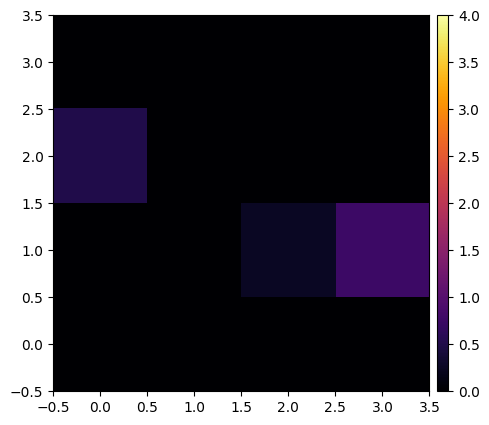

In [10]:
class PointGrid():
    '''Class to represent a signal grid at a specific location in the sky. Use `build` function to create the grid.'''

    def __init__(self, coordinates, factor=1, n_copies=1):
        check_type(coordinates, tuple, tuple, float)
        check_type(factor, int)
        check_type(n_copies, int)

        self.coordinates = coordinates
        self.factor = factor
        self.n_copies = n_copies
        self.shape = (1, 1)

    def __repr__(self):
        return f'PointGrid(coordinates={self.coordinates}, factor={self.factor}, n_copies={self.n_copies})'

    @property
    def coos(self):
        return np.array(self.coordinates)
    
    @property
    def shp(self):
        return np.array(self.shape)

    @property
    def size(self):
        return self.shp.prod()

    def update(self, coordinates=None, factor=None, n_copies=None):
        coordinates = self.coordinates if coordinates is None else coordinates
        factor = self.factor if factor is None else factor
        n_copies = self.n_copies if n_copies is None else n_copies
        return PointGrid(coordinates, factor, n_copies)



def map_point(in_array, in_grid, out_grid):
    if out_grid.factor < in_grid.factor:
        factor = out_grid.factor / in_grid.factor
        in_coos = np.floor(in_grid.coos * out_grid.factor) / out_grid.factor + 0.5 / out_grid.factor
        in_grid = in_grid.update(coordinates=tuple(map(tuple, in_coos.tolist())), factor=out_grid.factor)
    else:
        factor = out_grid.factor // in_grid.factor
        out_grid = out_grid.update(factor=in_grid.factor)

    out_array = np.zeros(out_grid.shape)

    for i in range(in_grid.n_copies):
        llp_dif = (out_grid.factor * (in_grid.coos[i] - out_grid.llp)).astype('int64')
        out_array[llp_dif[0], llp_dif[1]] += in_array[i,0,0] * factor**2
        
    if factor > 1:
        out_array = upsample(out_array, factor)

    return out_array


pg = PointGrid(coordinates=((0.125, -0.375), (-0.625, 0.375), (0.875, -0.125)), factor=4, n_copies=3)
sg = SignalGrid(space=(2,2), center=(0,0), factor=2)
print(pg)
print(pg.coos)
print(sg)
print(sg.llp, sg.urp)
# print(sg.coos[:,4,2])

pm = map_point(np.arange(1,4).reshape(3,1,1), pg, sg)
plot_arrays(pm, dpi=100, rows=1, vmin=-0, vmax=4)